# Tree models analysis


This report aims to compare different approaches to detecting tree areas in order to select the best one for the problem of analyzing changes in tree cover with the increase in the number of photovoltaic panel installations over years in 3City.

Metrics used for models evaluation:
- Intersection over Union (IoU)
- Dice Coefficient
- Mean Pixel Accuracy (mPA)
- Precision, Recall, F1-score (DeepForest)

Libraries 

In [1]:
from segment_anything import sam_model_registry, SamPredictor
import numpy as np
import torch
from PIL import Image
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation, AutoImageProcessor, SegformerForSemanticSegmentation
import cv2
from deepforest import main
import matplotlib.pyplot as plt

In [2]:
image_path = "img.jpg"
image_cv = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
image_pil = Image.open(image_path).convert("RGB")

In [5]:
def show_image(img, title=""):
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [3]:
def overlay_image_mask(image_pil, mask, color=(0, 255, 0), alpha=0.4):
    image = np.array(image_pil).copy()
    overlay = image.copy()
    overlay[mask == 1] = color
    blended = (image * (1 - alpha) + overlay * alpha).astype(np.uint8)
    return blended

## DeepForest + SAM


DeepForest is a model based on deep neural networks for automatic detection and segmentation of tree crowns in aerial or satellite images. It works by using convolutional neural networks (CNNs) to analyze images and recognize areas corresponding to individual trees. SAM (Segment Anything Model) uses transformer networks to automatically segment objects in images, regardless of their type or context. The model analyzes the image and creates segmentation masks. In the case of our problem, their cooperation would look like this: DeepForest provides tree locations (boxes), and SAM draws precisely the crown masks.

SAM models:
1. Most demanding: https://huggingface.co/facebook/sam-vit-huge

2. Medium: https://huggingface.co/facebook/sam-vit-base

3. Lightest: https://github.com/ChaoningZhang/MobileSAM

Pros:
- Both models are pre-trained
- We can always do fine-tuning on the deepforest model

Cons:
- Slow
- High resolution required

Reading config file: c:\Users\epaw0\AppData\Local\Programs\Python\Python312\Lib\site-packages\deepforest\data\deepforest_config.yml


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Reading config file: c:\Users\epaw0\AppData\Local\Programs\Python\Python312\Lib\site-packages\deepforest\data\deepforest_config.yml


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


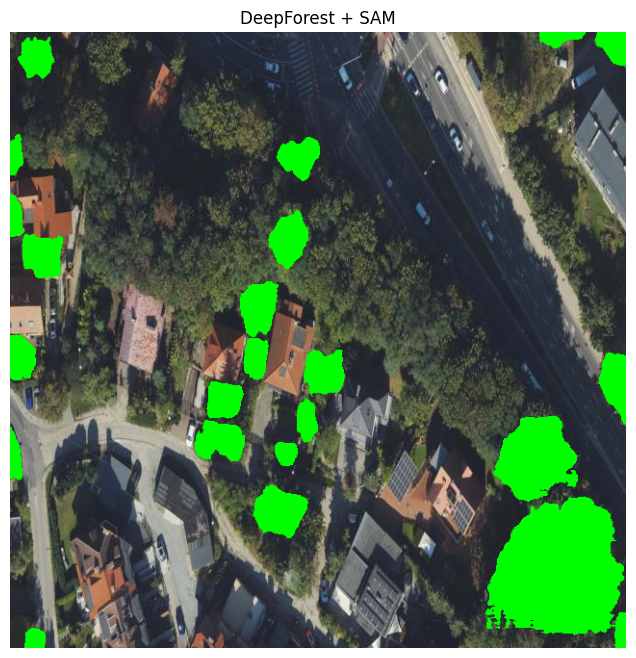

In [6]:
df_model = main.deepforest()
df_model.use_release()
boxes = df_model.predict_image(path=image_path, return_plot=False)

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
predictor = SamPredictor(sam)
predictor.set_image(image_rgb)


masks = []
for _, row in boxes.iterrows():
    box = np.array([[row["xmin"], row["ymin"]], [row["xmax"], row["ymax"]]])
    mask, score, _ = predictor.predict(box=box, multimask_output=False)
    masks.append(mask[0])

vis_image = image_rgb.copy()
for mask in masks:
    vis_image[mask] = (0, 255, 0)  

show_image(vis_image, "DeepForest + SAM")

## CLIPSeg (CLIP + Segmentation)

CLIPSeg is a model that combines text and visual representations from CLIP to perform image segmentation based on text descriptions (prompts). It works by generating a probability map showing which regions of the image correspond to a given text, using transformers to jointly process information from the image and text.

Source: https://huggingface.co/docs/transformers/model_doc/clipseg

Pros:
- Pre-trained model
- It allows segmentation of any objects without the need for additional training, a text description is enough.

Cons:
- Slow
- Imprecise for small objects
- Need to test different prompts to get good results

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


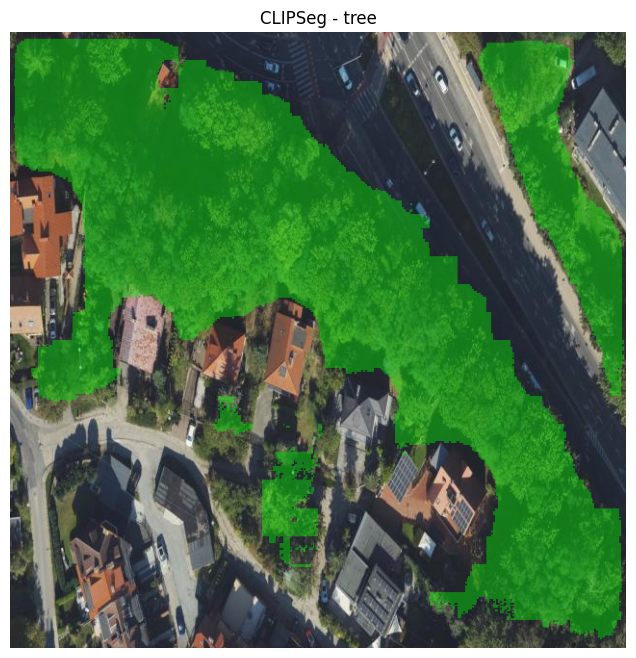

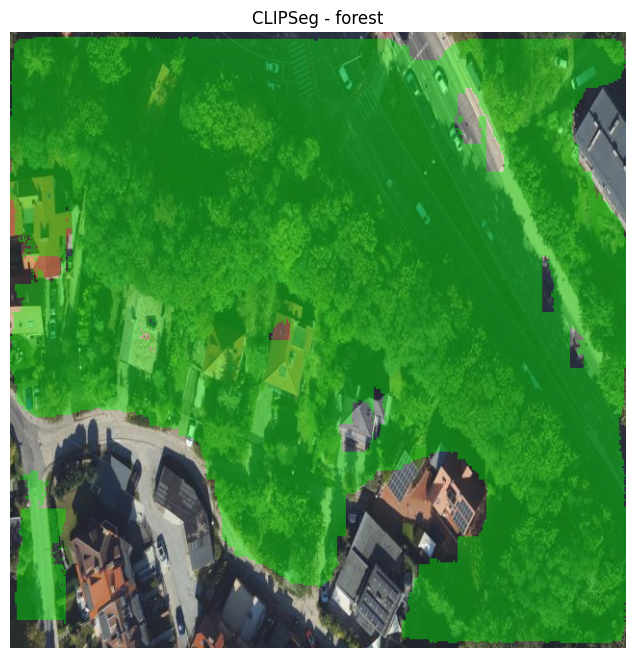

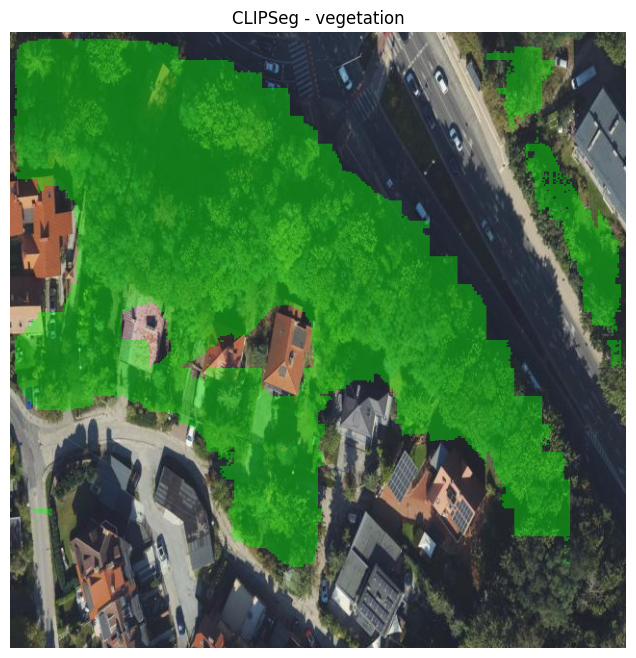

In [7]:
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

image = Image.open("img.jpg")
prompt = ["tree", "forest", "vegetation"]

inputs = processor(text=prompt, images=[image]*len(prompt), return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

for p in range(3):
    mask = torch.sigmoid(outputs.logits[p]).numpy()
    binary_mask = (mask > 0.5).astype(np.uint8)
    binary_mask_resized = np.array(
        Image.fromarray((binary_mask * 255).astype(np.uint8)).resize(image.size, Image.NEAREST)) // 255

    blended = overlay_image_mask(image, binary_mask_resized)
    show_image(blended, "CLIPSeg - " + prompt[p])


## SegFormer (semantic segmentation)


SegFormer is a semantic segmentation model based on the Pyramid Vision Transformer (PVTv2) architecture that combines the strengths of transformers and convolutional networks. It uses multi-scale image representations to accurately segment objects of various sizes and employs a lightweight decoding head for efficient and high-performance segmentation without complex training.

Source: https://huggingface.co/restor/tcd-segformer-mit-b2

Pros:
- Pre-trained model
- We can always do fine-tuning on the model
- Good solution if we want to measure the area around the PV panel

Cons:
- The model was trained on images of ~10 cm/pixel, so with another size there may be a problem
- Can be imprecise for small objects


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


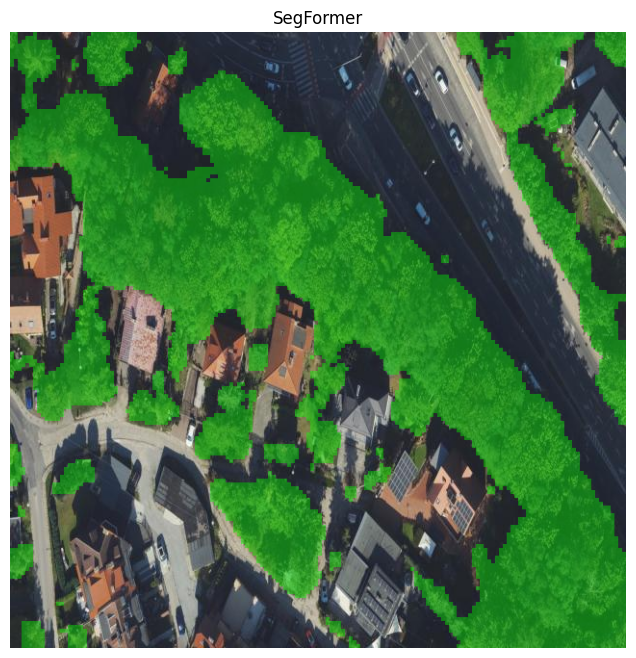

In [8]:
processor = AutoImageProcessor.from_pretrained("restor/tcd-segformer-mit-b2")
model = SegformerForSemanticSegmentation.from_pretrained("restor/tcd-segformer-mit-b2")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
mask = outputs.logits.argmax(dim=1).squeeze().cpu().numpy()
mask_resized = np.array(Image.fromarray(mask.astype(np.uint8)).resize(image.size))

blended = overlay_image_mask(image, mask_resized)
show_image(blended, "SegFormer")

## Conclusions and final selection

#TO DO 

The best is SegFormer